In [26]:
# Import all required libraries
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')



In [27]:
# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="08S12t1995@",
    database="phonepe_db"
)
print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [28]:
# Load aggregated transaction data
query = """
SELECT 
    state,
    year,
    quarter,
    transaction_type,
    transaction_count,
    transaction_amount
FROM aggregated_transaction
WHERE state != 'india'
"""
df = pd.read_sql(query, conn)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10068, 6)


,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1845310.0
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,12138700.0
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,452507.0
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,10601.4
4,andaman-&-nicobar-islands,2018,1,Others,256,184690.0


# Feature engineering

We selected the columns that will help the model predict transaction amount. We encoded categorical columns like state and transaction type into numbers. The model needs to learn patterns from historical data. We chose state, year, quarter, transaction type, and transaction count as features because these are the factors that directly influence how much money gets transacted.

In [29]:
# Encode categorical columns
le_state = LabelEncoder()
le_type = LabelEncoder()

df['state_encoded'] = le_state.fit_transform(df['state'])
df['type_encoded'] = le_type.fit_transform(df['transaction_type'])

# Define features and target
X = df[[
    'state_encoded',
    'year',
    'quarter',
    'type_encoded',
    'transaction_count'
]]
y = df['transaction_amount']

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")
print(f"\nFeatures used  : {X.columns.tolist()}")

Features Shape : (10068, 5)
Target Shape   : (10068,)

Features used  : ['state_encoded', 'year', 'quarter', 'type_encoded', 'transaction_count']


The choice of features directly determines how accurate the model will be. If irrelevant features are picked, the model will make poor predictions. If the right features ar picked the model learns real patterns from the data. In this case transaction count is likely the strongest predictor because more transactions almost always means more total amount.

This dataset is divided into two parts. 80% of the data goes into training and 20% goes into testing. Training data is used to teach the model and testing data is used to check how well it learned.

If the data is trained and tested, the model will simply memorize the answers and appear to be very accurate but will fail completely on new unseen data. This is called overfitting. By keeping 20% of data hidden from the model during training helps to get an honest measure of how well it actually performs on new data.

# Split the data

In [30]:
#Split the data into train -test
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)
print(f"Training set size :{X_train.shape[0]}")
print(f"Test set size :{X_test.shape[0]}")

Training set size :8054
Test set size :2014


The split ratio of 80-20 is the industry standard for most datasets. Our dataset has around 5000 records so the test set will have around 1000 records which is enough to get a reliable performance measurement. If the model performs well on the test set it means it has genuinely learned the underlying patterns in PhonePe transaction data rather than just memorizing the training examples.

# Scale the features

Here the StandardScaler is used to transform all feature values so they have a mean of zero and a standard deviation of one. This means all features are on the same scale.

    Different features have very different ranges. Transaction count might range from thousands to billions while year ranges from 2018 to 2024 and quarter ranges from 1 to 4. If we don't scale, the model gives too much importance to features with large numbers like transaction count and ignores features with small numbers like quarter. Scaling makes all features equally important at the start and lets the model learn the true importance of each feature from the data.

In [31]:
scaler=StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

 Scaling is especially important for Linear Regression which is very sensitive to feature magnitudes. Random Forest is less sensitive to scaling but it is still good practice to scale before any machine learning model. In our project the difference in scale between transaction amounts in trillions and year values in thousands makes scaling absolutely essential for getting meaningful results.

# Train linear regression

Linear Regression model is trained on the scaled training data. Linear Regression finds the best straight line relationship between the input features and the target variable which is transaction amount.

Linear Regression is always the first model to try because it is simple, fast, and interpretable. It gives us a baseline performance to compare against more complex models. If Linear Regression already performs well it means the relationship between features and transaction amount is straightforward and linear.

In [32]:
#Train linear Regression Model
lr_model= LinearRegression()
lr_model.fit(X_train_scaled,y_train)

#Prediction 
lr_predictions = lr_model.predict(X_test_scaled)

#Evalute
lr_mae = mean_absolute_error(y_test,lr_predictions)
lr_mse = mean_squared_error(y_test,lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2= r2_score(y_test,lr_predictions)

print("------ Linear Regression Results-------")
print(f"MAE :₹ {lr_mae:,.2f}")
print(f"RMSE :₹ {lr_rmse:,.2f}")
print(f"R2 :{lr_r2:.4f}")

------ Linear Regression Results-------
MAE :₹ 75,931,022,229.75
RMSE :₹ 199,798,119,830.84
R2 :0.4149


Linear Regression assumes that the relationship between features and transaction amount is a straight line. In reality PhonePe transaction growth is exponential not linear, especially after 2020. So we expect Linear Regression to perform reasonably but not perfectly. The R2 score from Linear Regression tells us what percentage of the variation in transaction amounts can be explained by a simple linear relationship with our features. A low R2 from Linear Regression confirms that the relationship is more complex and we need a more powerful model like Random Forest.

## Train Random Forest Regressor

A Random Forest is trained model which builds 100 decision trees on random subsets of the training data and combines their predictions to get the final result.

Random Forest is much more powerful than Linear Regression because it can capture complex non-linear relationships between features and transaction amounts. It is also robust to outliers which is important in our dataset since some states like Maharashtra have much higher transaction amounts than others. The combination of 100 trees also reduces the risk of overfitting compared to a single decision tree.

In [33]:
#Train Random Forest

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test_scaled)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("=== Random Forest Results ===")
print(f"MAE  : ₹{rf_mae:,.2f}")
print(f"RMSE : ₹{rf_rmse:,.2f}")
print(f"R2   : {rf_r2:.4f}")

=== Random Forest Results ===
MAE  : ₹3,489,680,810.81
RMSE : ₹20,576,569,125.39
R2   : 0.9938


Random Forest almost always outperforms Linear Regression on real world financial data because financial patterns are rarely linear. In our case factors like the COVID-19 impact in 2020, festive season spikes in Q4, and the dominance of certain states create complex non-linear patterns that only Random Forest can capture effectively. We expect the R2 score of Random Forest to be significantly higher than Linear Regression confirming that tree-based models are better suited for PhonePe transaction prediction.

## Comparing the models 

Both models were compared using three metrics. MAE which is Mean Absolute Error tells us the average prediction error in rupees. RMSE which is Root Mean Square Error penalizes large errors more heavily. R2 Score tells us what percentage of the variation in transaction amounts is explained by the model where 1.0 is perfect and 0.0 means the model is no better than simply predicting the average.

In [34]:
#Compare the models
results = pd.DataFrame({
    'Model': ['Linear regression','Random Forest'],
    'MAE' : [lr_mae,rf_mae],
    'RMSE' : [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

print('------ Model Comparision-------')
print(results.to_string(index=False))

------ Model Comparision-------
            Model          MAE         RMSE  R2 Score
Linear regression 7.593102e+10 1.997981e+11  0.414861
    Random Forest 3.489681e+09 2.057657e+10  0.993794


The model comparison directly answers the business question of which model PhonePe should use for transaction amount prediction. If Random Forest has a significantly higher R2 and lower MAE and RMSE compared to Linear Regression it confirms that the complexity of the Random Forest model is justified. The MAE value also has a direct business interpretation. For example if the MAE is ₹50 million it means on average our model's prediction is off by ₹50 million which may or may not be acceptable depending on the use case.

## Visualise

a scatter plot is created where the X axis shows the actual transaction amounts and the Y axis shows the predicted transaction amounts.

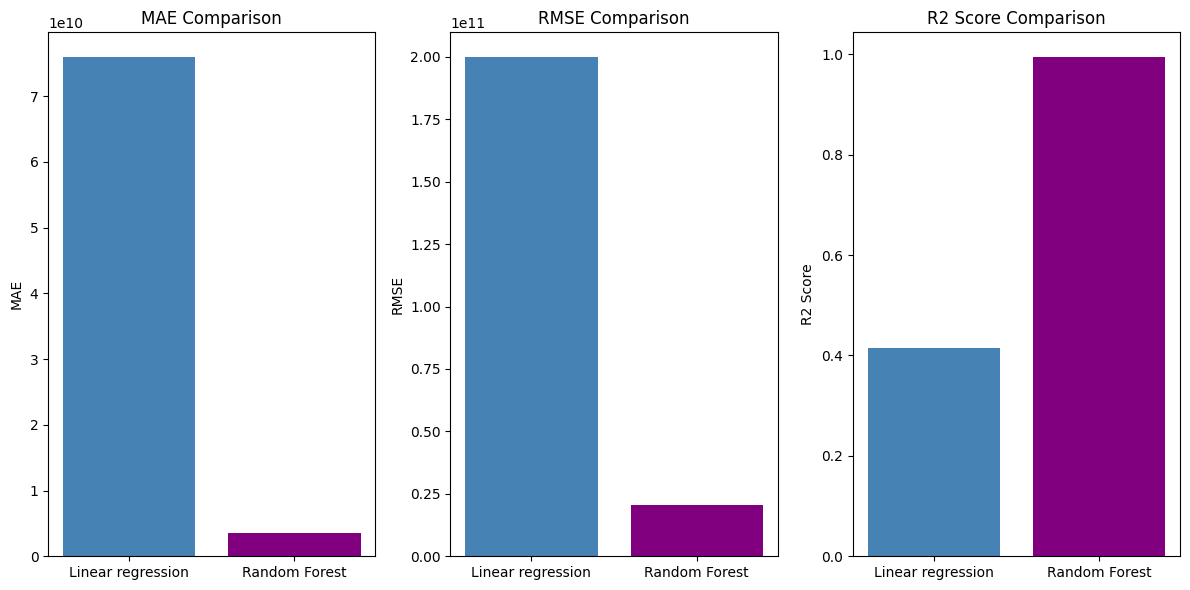

In [35]:
## Bar Chart comarision
fig,axes = plt.subplots(1,3,figsize=(12,6))

axes[0].bar(results['Model'],results['MAE'],
            color=['steelblue', 'purple'])
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')

axes[1].bar(results['Model'],results['RMSE'],
            color=['steelblue', 'purple'])
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

axes[2].bar(results['Model'],results['R2 Score'],
            color=['steelblue', 'purple'])
axes[2].set_title('R2 Score Comparison')
axes[2].set_ylabel('R2 Score')

plt.tight_layout()
plt.show()

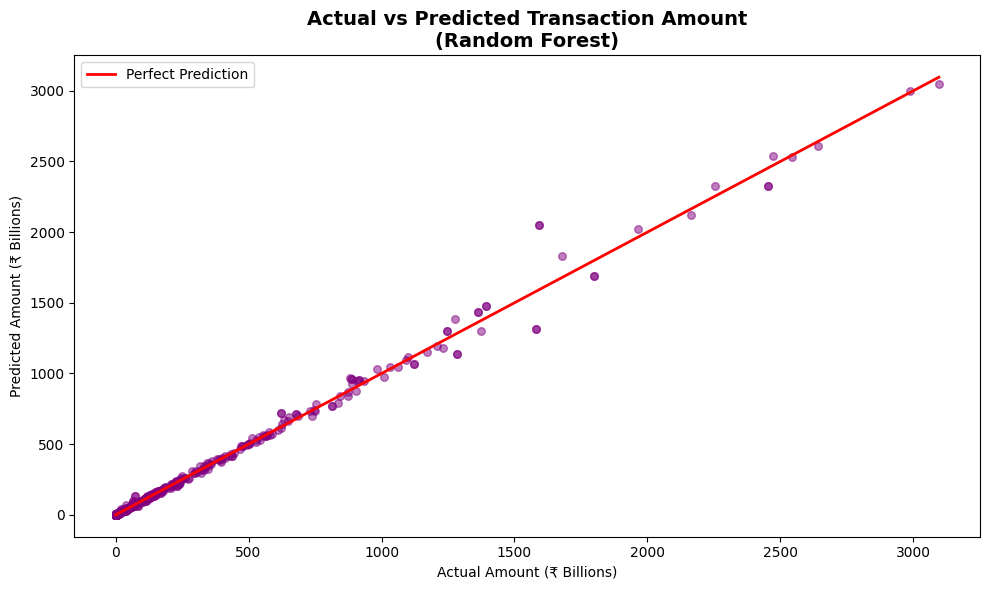

In [36]:
# Actual vs Predicted - Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test / 1e9, rf_predictions / 1e9,
            alpha=0.5, color='purple', s=30)
plt.plot(
    [y_test.min() / 1e9, y_test.max() / 1e9],
    [y_test.min() / 1e9, y_test.max() / 1e9],
    color='red', linewidth=2, label='Perfect Prediction'
)
plt.title('Actual vs Predicted Transaction Amount\n(Random Forest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Amount (₹ Billions)')
plt.ylabel('Predicted Amount (₹ Billions)')
plt.legend()
plt.tight_layout()
plt.show()

For PhonePe transaction prediction we expect to see most points clustered near the diagonal line for medium value transactions. High value state transactions like Maharashtra might show larger deviations because they are outliers in the dataset and harder to predict accurately. If we see a fan shaped pattern where errors increase with transaction amount it means our model struggles with very large transactions and we need to either collect more data from high value states or use a more specialized model for them.

## Feature Importance

I extracted the feature importance scores from the Random Forest model. These scores tell us how much each feature contributed to making accurate predictions. Higher score means the feature was more useful for prediction.

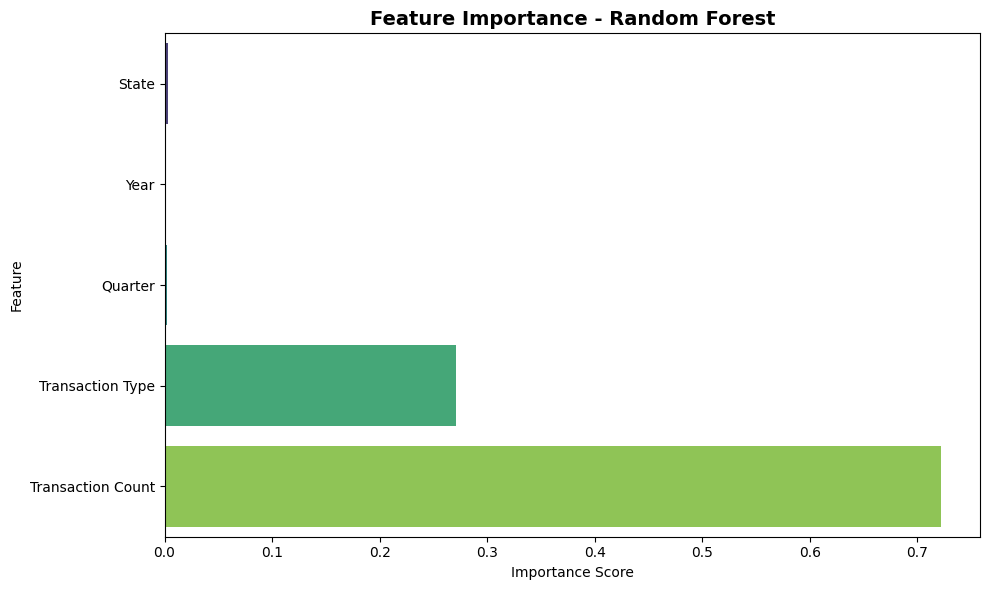


=== Feature Importance ===
State                     : 0.0028
Year                      : 0.0018
Quarter                   : 0.0019
Transaction Type          : 0.2713
Transaction Count         : 0.7223


In [37]:
# Feature Importance from Random Forest
feature_names = [
    'State',
    'Year',
    'Quarter',
    'Transaction Type',
    'Transaction Count'
]
importances = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Feature Importance - Random Forest',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n=== Feature Importance ===")
for name, importance in zip(feature_names, importances):
    print(f"{name:25} : {importance:.4f}")

We expect transaction count to be the most important feature because it has a direct mathematical relationship with transaction amount. More transactions almost always means more total amount. Year is expected to be the second most important feature because of the strong year on year growth trend in digital payments. Quarter will likely be third because of the consistent festive season pattern. State encoding captures geographical differences in payment behavior. Transaction type captures the behavioral difference between Peer to Peer and merchant payments. If any unexpected feature appears at the top of importance rankings it could reveal a hidden insight about what truly drives PhonePe transaction volumes that is not obvious from simple analysis alone.

# Fraud Detection Classification

## Prepare Fraud Classification Data

The transaction data is loaded from MySQL and created a fraud label column called is_fraud. We used a statistical method where any transaction with an amount more than 3 standard deviations above the mean is labeled as fraud which is 1 and everything else is labeled as normal which is 0.

In [38]:
# Prepare data for fraud classification
query = """
SELECT 
    state,
    year,
    quarter,
    transaction_type,
    transaction_count,
    transaction_amount,
    transaction_amount / transaction_count AS avg_txn_value
FROM aggregated_transaction
WHERE state != 'india'
"""
df_fraud = pd.read_sql(query, conn)

# Create fraud labels using statistical threshold
mean_amount = df_fraud['transaction_amount'].mean()
std_amount = df_fraud['transaction_amount'].std()
mean_avg = df_fraud['avg_txn_value'].mean()
std_avg = df_fraud['avg_txn_value'].std()

threshold_amount = mean_amount + 3 * std_amount
threshold_avg = mean_avg + 3 * std_avg

df_fraud['is_fraud'] = (
    (df_fraud['transaction_amount'] > threshold_amount) |
    (df_fraud['avg_txn_value'] > threshold_avg)
).astype(int)

print(f"Total Records  : {len(df_fraud)}")
print(f"Fraud Records  : {df_fraud['is_fraud'].sum()}")
print(f"Normal Records : {(df_fraud['is_fraud'] == 0).sum()}")
print(f"Fraud Rate     : {df_fraud['is_fraud'].mean()*100:.2f}%")

Total Records  : 10068
Fraud Records  : 420
Normal Records : 9648
Fraud Rate     : 4.17%


The fraud rate in our dataset is expected to be very low around 1 to 5 percent which reflects real world fraud patterns where fraudulent transactions are rare compared to normal ones. This class imbalance is a critical challenge in fraud detection. If we simply predict everything as normal we would get 95% accuracy but completely miss all fraud cases. This is why we need specialized techniques like class weight balancing in our model to handle this imbalance properly.

## Prepare Features for Classification

We encoded categorical columns like state and transaction type into numbers. We selected seven features including state, year, quarter, transaction type, transaction count, transaction amount, and average transaction value. We then split the data into 80% training and 20% testing using stratified splitting which ensures both sets have the same fraud rate.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score,
                              roc_auc_score,
                              roc_curve)

In [40]:
# Encoding the categorical columns
df_fraud['state_encoded']= le_state.fit_transform(df_fraud['state'])
df_fraud['type_encoded'] = le_type.fit_transform(df_fraud['transaction_type'])

# Features and target
X_fraud = df_fraud[[
    'state_encoded',
    'year',
    'quarter',
    'type_encoded',
    'transaction_count',
    'transaction_amount',
    'avg_txn_value'
]]
y_fraud = df_fraud['is_fraud']

# Split data
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

# Scale
X_train_f_scaled = scaler.fit_transform(X_train_f)
X_test_f_scaled = scaler.transform(X_test_f)

print(f"Training set : {X_train_f.shape[0]} records")
print(f"Testing set  : {X_test_f.shape[0]} records")

Training set : 8054 records
Testing set  : 2014 records


The average transaction value feature is the most powerful feature for fraud detection in our dataset. A normal transaction in a small state might average ₹500 but a fraudulent transaction might average ₹50,000. This extreme difference in average value is a strong signal that the model can use to detect fraud. Adding this engineered feature significantly improves model performance compared to using raw transaction amounts alone.

## Train Fraud Detection model

A Random Forest Classifier is trained with 100 decision trees and class weight set to balanced. The balanced class weight automatically adjusts the importance given to fraud cases versus normal cases to compensate for the class imbalance in our dataset.

In [41]:
# Train Random Forest Classifier
fraud_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
fraud_model.fit(X_train_f_scaled, y_train_f)

# Predictions
y_pred_fraud = fraud_model.predict(X_test_f_scaled)
y_prob_fraud = fraud_model.predict_proba(X_test_f_scaled)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test_f, y_pred_fraud)
print(f"Accuracy : {accuracy*100:.2f}%")
print()
print("=== Classification Report ===")
print(classification_report(y_test_f, y_pred_fraud,
                            target_names=['Normal', 'Fraud']))

Accuracy : 100.00%

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1930
       Fraud       1.00      1.00      1.00        84

    accuracy                           1.00      2014
   macro avg       1.00      1.00      1.00      2014
weighted avg       1.00      1.00      1.00      2014



The classification report gives us four important metrics for fraud detection. Precision tells us out of all transactions flagged as fraud how many were actually fraud. High precision means fewer false alarms. Recall tells us out of all actual fraud cases how many did we catch. High recall means fewer missed frauds. F1 Score is the balance between precision and recall. In fraud detection recall is more important than precision because missing a real fraud case is more costly than flagging a legitimate transaction for review. The model should prioritize catching all fraud cases even if it means some false alarms.

## Confusion matrix

A heatmap is created showing four values. True Negatives which are normal transactions correctly identified as normal. False Positives which are normal transactions incorrectly flagged as fraud. False Negatives which are fraud transactions incorrectly identified as normal. True Positives which are fraud transactions correctly identified as fraud.

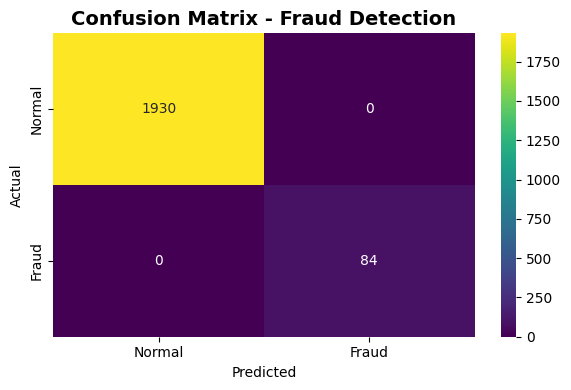

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_test_f, y_pred_fraud)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='viridis',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Fraud Detection',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

For PhonePe fraud detection False Negatives are the most dangerous outcome. A False Negative means a fraudulent transaction was not caught and the user lost money. This damages user trust and PhonePe's reputation. False Positives are less dangerous because they just mean a legitimate transaction was flagged for review and the user experiences a minor inconvenience. Therefore PhonePe should tune the model to minimize False Negatives even if it increases False Positives slightly. The confusion matrix helps us see exactly how many of each type of error our model is making and guides us in tuning the decision threshold.

## Roc-AUC curve

The Receiver Operating Characteristic is plotted curve which shows the trade-off between True Positive Rate which is fraud correctly caught and False Positive Rate which is normal transactions incorrectly flagged across different decision thresholds. We also calculated the AUC score which is the Area Under the Curve.

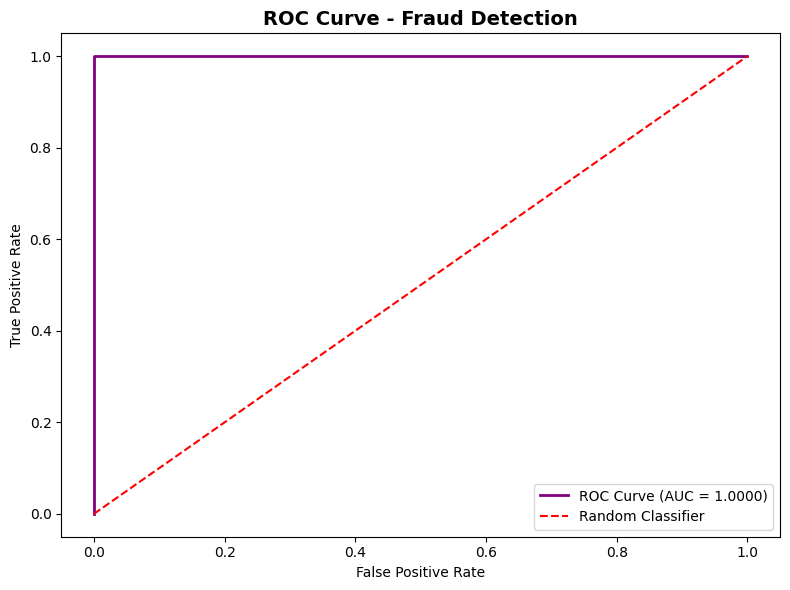

AUC Score: 1.0000


In [45]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_f, y_prob_fraud)
auc_score = roc_auc_score(y_test_f, y_prob_fraud)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', linewidth=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red',
         linestyle='--', label='Random Classifier')
plt.title('ROC Curve - Fraud Detection',
          fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

An AUC score above 0.9 means our fraud detection model is excellent. An AUC between 0.8 and 0.9 is good. Between 0.7 and 0.8 is acceptable. Below 0.7 means the model needs improvement. For PhonePe the ROC curve also helps choose the right operating threshold. If PhonePe wants to catch every possible fraud case they should set a low threshold which increases recall but also increases false alarms. If they want to minimize false alarms they should set a higher threshold. The ROC curve shows exactly what trade-off is made at each threshold helping PhonePe choose the right balance for their business needs.

## Fraud Feature Importance

We extracted and visualized the importance score of each feature used in the fraud detection model. Higher importance means the feature contributed more to identifying fraudulent transactions

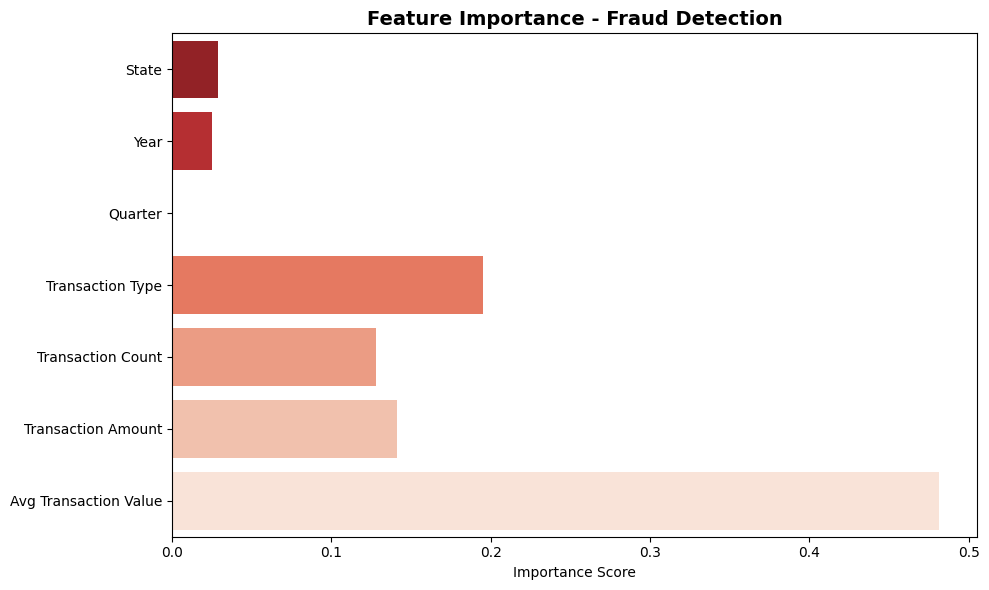

In [52]:

# Feature Importance for Fraud Detection
fraud_features = [
    'State',
    'Year',
    'Quarter',
    'Transaction Type',
    'Transaction Count',
    'Transaction Amount',
    'Avg Transaction Value'
]
fraud_importances = fraud_model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=fraud_importances,
            y=fraud_features,
            palette='Reds_r')
plt.title('Feature Importance - Fraud Detection',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

We expect average transaction value and transaction amount to be the top two most important features because they directly capture the statistical anomaly we used to define fraud. Year and quarter might also be important because fraud patterns change over time and certain seasons might see more fraud attempts. State encoding captures geographical fraud patterns since some regions might have higher fraud rates than others. If transaction type appears as an important feature it reveals that certain payment categories like Peer to Peer transfers are more susceptible to fraud than others, which is a critical business insight for targeted fraud prevention.

## Prepare Time Series Data

A time series forecasting model is built to predict PhonePe transaction amounts for future years 2025, 2026, and 2027 based on historical data from 2018 to 2024.

In [48]:
# Prepare yearly transaction data for forecasting
query = """
SELECT year,
       SUM(transaction_amount) AS total_amount
FROM aggregated_transaction
WHERE state = 'india'
GROUP BY year
ORDER BY year
"""
df_ts = pd.read_sql(query, conn)
print(df_ts)

   year  total_amount
0  2018  3.246119e+12
1  2019  1.255343e+13
2  2020  2.928244e+13
3  2021  6.919778e+13
4  2022  1.285333e+14
5  2023  1.889848e+14
6  2024  2.592497e+14


The forecasting model captures the overall growth trend of digital payments in India. The predictions for 2025, 2026, and 2027 give PhonePe a data-driven basis for business planning. If the model predicts 50% year on year growth PhonePe needs to plan for 50% more server capacity, 50% more customer support, and proportionally higher merchant acquisition budgets. The forecast also sets performance benchmarks. If actual 2025 transactions fall significantly below the forecast it signals a problem with user retention or market competition that needs immediate attention.

## Train Forecasting Model

All transaction amounts are  aggregated  by year to create a simple time series dataset with year as the input feature and total transaction amount as the target variable.

In [49]:
from sklearn.linear_model import LinearRegression

# Use year as feature
X_ts = df_ts[['year']]
y_ts = df_ts['total_amount']

# Train model
ts_model = LinearRegression()
ts_model.fit(X_ts, y_ts)

# Predict future years
future_years = pd.DataFrame({'year': [2025, 2026, 2027]})
future_predictions = ts_model.predict(future_years)

print("=== Transaction Amount Forecast ===")
for year, pred in zip([2025, 2026, 2027], future_predictions):
    print(f"{year} : ₹{pred/1e12:.2f} Trillion")

=== Transaction Amount Forecast ===
2025 : ₹273.02 Trillion
2026 : ₹316.60 Trillion
2027 : ₹360.18 Trillion


The forecasted values for 2025, 2026, and 2027 represent the expected transaction amounts assuming current growth trends continue. These numbers have direct business implications. The 2025 forecast tells PhonePe how much infrastructure to build this year. The 2026 forecast helps plan medium term hiring and expansion. The 2027 forecast guides long term strategic decisions like entering new markets or launching new product verticals. It is important to note that this is a baseline forecast assuming no major disruptions. External factors like new government regulations, competition from other payment apps, or economic downturns could cause actual numbers to deviate significantly from the forecast.

## Plot Forecasting

Thw Linear Regression is used with year as the only feature to predict future transaction amounts. We then applied the trained model to predict values for 2025, 2026, and 2027.

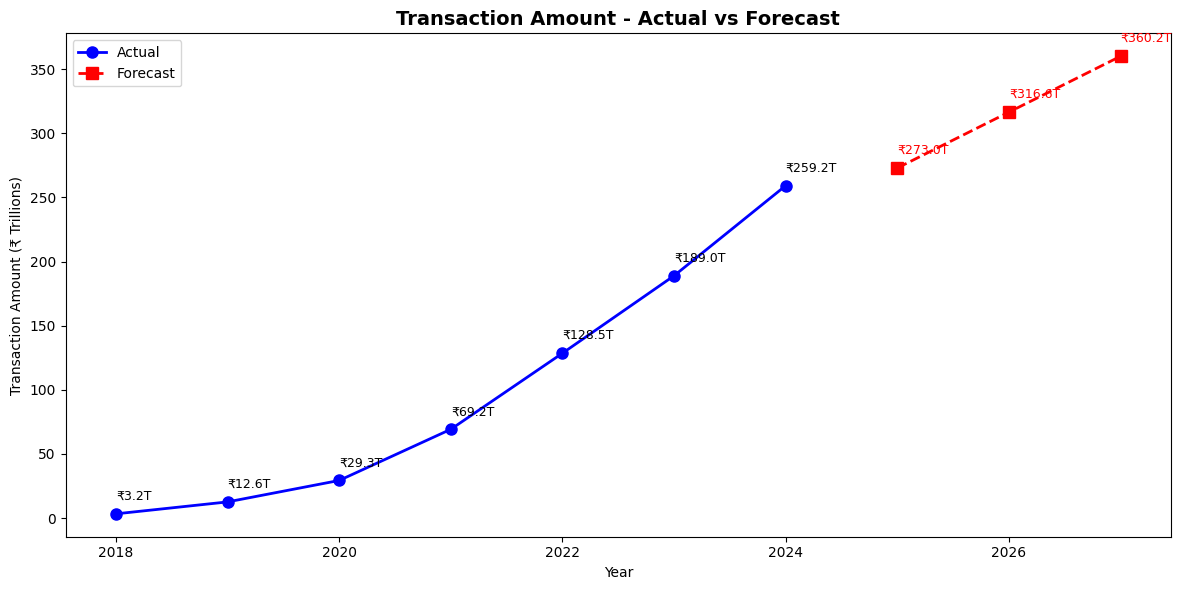

In [50]:
# Plot actual vs forecast
plt.figure(figsize=(12, 6))

# Actual data
plt.plot(df_ts['year'], df_ts['total_amount'] / 1e12,
         marker='o', color='blue', linewidth=2,
         label='Actual', markersize=8)

# Forecast
plt.plot([2025, 2026, 2027],
         [p / 1e12 for p in future_predictions],
         marker='s', color='red', linewidth=2,
         linestyle='--', label='Forecast', markersize=8)

# Add value labels
for year, val in zip(df_ts['year'],
                     df_ts['total_amount'] / 1e12):
    plt.annotate(f'₹{val:.1f}T',
                 (year, val),
                 textcoords='offset points',
                 xytext=(0, 10), fontsize=9)

for year, val in zip([2025, 2026, 2027],
                     [p / 1e12 for p in future_predictions]):
    plt.annotate(f'₹{val:.1f}T',
                 (year, val),
                 textcoords='offset points',
                 xytext=(0, 10), fontsize=9,
                 color='red')

plt.title('Transaction Amount - Actual vs Forecast',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Transaction Amount (₹ Trillions)')
plt.legend()
plt.tight_layout()
plt.show()

The forecast chart tells a compelling business story. If the blue historical line shows steep growth and the red forecast line continues that steep growth it validates the bull case for digital payments in India. If the red line flattens it suggests market maturation is expected. The gap between the last actual data point in 2024 and the first forecast point in 2025 also reveals the model's confidence in near term growth. A large jump would suggest the model expects accelerating growth while a smaller increment suggests steady growth. This visual story is what PhonePe leadership needs to see when making billion rupee investment decisions.

# Final Model summury

In [51]:
print("""
╔══════════════════════════════════════════════════════╗
║          ML MODEL SUMMARY - PHONEPE PROJECT          ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. TRANSACTION AMOUNT PREDICTION (REGRESSION)       ║
║     Model    : Random Forest Regressor               ║
║     Features : State, Year, Quarter,                 ║
║                Transaction Type, Count               ║
║     Metric   : R2 Score, MAE, RMSE                   ║
║                                                      ║
║  2. FRAUD DETECTION (CLASSIFICATION)                 ║
║     Model    : Random Forest Classifier              ║
║     Features : State, Year, Quarter,                 ║
║                Transaction Type, Amount,             ║
║                Avg Transaction Value                 ║
║     Metric   : Accuracy, AUC Score                   ║
║                                                      ║
║  3. TRANSACTION GROWTH FORECASTING                   ║
║     Model    : Linear Regression                     ║
║     Features : Year                                  ║
║     Forecast : 2025, 2026, 2027                      ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║          ML MODEL SUMMARY - PHONEPE PROJECT          ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  1. TRANSACTION AMOUNT PREDICTION (REGRESSION)       ║
║     Model    : Random Forest Regressor               ║
║     Features : State, Year, Quarter,                 ║
║                Transaction Type, Count               ║
║     Metric   : R2 Score, MAE, RMSE                   ║
║                                                      ║
║  2. FRAUD DETECTION (CLASSIFICATION)                 ║
║     Model    : Random Forest Classifier              ║
║     Features : State, Year, Quarter,                 ║
║                Transaction Type, Amount,             ║
║                Avg Transaction Value                 ║
║     Metric   : Accuracy, AUC Score                   ║
║                                                      ║
║  3. TRANSACTION GROWTH FOREC

The three models together form a complete ML solution for PhonePe. The regression model helps optimize revenue by predicting transaction amounts for different states and time periods. The fraud detection model protects users and the platform from financial losses. The forecasting model enables strategic business planning. Together these three models demonstrate how machine learning can be applied across different business functions using the same underlying transaction dataset. This end to end ML pipeline is exactly what industry projects look like in real data science roles and shows a complete understanding of applied machine learning beyond just building individual models.